In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
from scipy.stats import bartlett, gaussian_kde, shapiro, probplot

In [74]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df = df.sample(n=30000, random_state=42)

print(f"Размер датасета: {df.shape}")
print(f"Количество признаков: {df.shape[1] - 1}")  # минус целевая переменная
print(f"Количество объектов: {df.shape[0]}\n")
df.info()

Размер датасета: (30000, 22)
Количество признаков: 21
Количество объектов: 30000

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 219620 to 29091
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_012          30000 non-null  float64
 1   HighBP                30000 non-null  float64
 2   HighChol              30000 non-null  float64
 3   CholCheck             30000 non-null  float64
 4   BMI                   30000 non-null  float64
 5   Smoker                30000 non-null  float64
 6   Stroke                30000 non-null  float64
 7   HeartDiseaseorAttack  30000 non-null  float64
 8   PhysActivity          30000 non-null  float64
 9   Fruits                30000 non-null  float64
 10  Veggies               30000 non-null  float64
 11  HvyAlcoholConsump     30000 non-null  float64
 12  AnyHealthcare         30000 non-null  float64
 13  NoDocbcCost           30000 non-null  f

In [75]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,30000.0,0.290367,0.691474,0.0,0.0,0.0,0.0,2.0
HighBP,30000.0,0.433467,0.495562,0.0,0.0,0.0,1.0,1.0
HighChol,30000.0,0.426133,0.494522,0.0,0.0,0.0,1.0,1.0
CholCheck,30000.0,0.962433,0.190149,0.0,1.0,1.0,1.0,1.0
BMI,30000.0,28.443900,6.584023,12.0,24.0,27.0,31.0,95.0
Smoker,30000.0,0.444000,0.496862,0.0,0.0,0.0,1.0,1.0
Stroke,30000.0,0.039600,0.195021,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,30000.0,0.093667,0.291369,0.0,0.0,0.0,0.0,1.0
PhysActivity,30000.0,0.757167,0.428802,0.0,1.0,1.0,1.0,1.0
Fruits,30000.0,0.632867,0.482031,0.0,0.0,1.0,1.0,1.0


📏 ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ

📊 РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ:


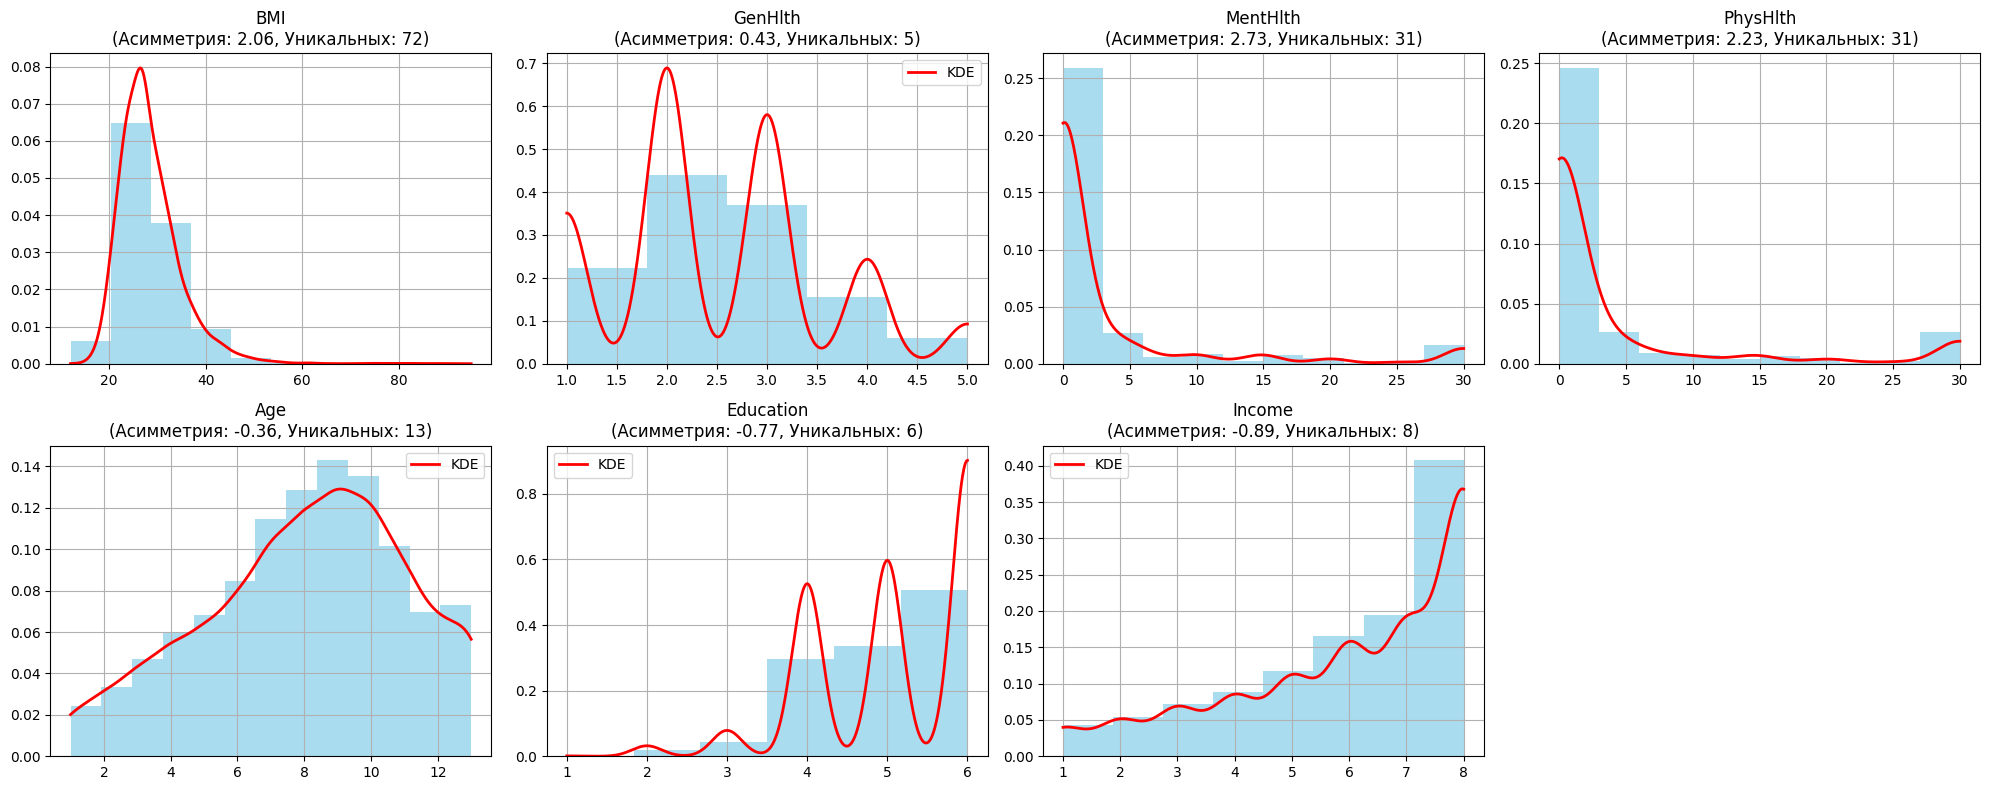

In [76]:
print("📏 ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ")

bools = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
                                   'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
                                   'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                                   'NoDocbcCost', 'DiffWalk', 'Sex']
cats = ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

target = df[['Diabetes_012']]
all_features = df.drop(target.columns, axis=1)
bool_feat = df[bools]
features = all_features.drop(bool_feat.columns, axis=1)
cats_feat = df[cats]
# features = features.drop(cats_feat.columns, axis=1)
hist_features = features.columns

# Визуальная проверка распределений
print("\n📊 РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ:")
n_cols = 4
n_rows = (len(hist_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(hist_features):
    data = df[feature].dropna()
    
    # Определяем, является ли переменная дискретной
    n_unique = data.nunique()
    is_discrete = n_unique <= 30  # Если меньше 20 уникальных значений - считаем дискретной
    
    # Настройка сглаживания в зависимости от типа данных
    if is_discrete:
        data.hist(ax=axes[i], alpha=0.7, color='skyblue', density=True, bins=n_unique)
        # Для дискретных данных используем большее сглаживание
        label = 'KDE (сглаженная)'
    else:
        data.hist(ax=axes[i], alpha=0.7, color='skyblue', density=True)
        # Для непрерывных данных - стандартное сглаживание
        label = 'KDE'
    
    kde = gaussian_kde(data)
    kde.set_bandwidth(kde.factor * 1.5)  # Увеличиваем ширину полосы на 50%
    
    x_range = np.linspace(data.min(), data.max(), 1000)
    axes[i].plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
    
    axes[i].set_title(f'{feature}\n(Асимметрия: {data.skew():.2f}, Уникальных: {n_unique})')
    axes[i].set_xlabel('')
    if is_discrete:
        axes[i].legend()
    
# Скрываем пустые subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [77]:
normality_results = []
for feature in all_features:
    stat, p_value = shapiro(df[feature])
    normality_results.append({
        'Признак': feature,
        'Статистика': stat,
        'p-value': p_value,
        'Нормальное': p_value > 0.05
    })

normality_df = pd.DataFrame(normality_results)
display(normality_df)

normal_count = normality_df['Нормальное'].sum()
total_count = len(normality_df)
print(f"\n📊 Результат: {normal_count}/{total_count} признаков имеют нормальное распределение")

c:\Dev\MDA\MDA3\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30000.
  res = hypotest_fun_out(*samples, **kwds)


,Признак,Статистика,p-value,Нормальное
0,HighBP,0.630157,4.978633e-119,False
1,HighChol,0.628644,3.837122e-119,False
2,CholCheck,0.185415,6.496165e-142,False
3,BMI,0.875794,9.206579e-91,False
4,Smoker,0.632049,6.903961e-119,False
5,Stroke,0.192080,1.151517e-141,False
6,HeartDiseaseorAttack,0.329557,4.428096e-136,False
7,PhysActivity,0.532359,1.288829e-125,False
8,Fruits,0.610439,1.796391e-120,False
9,Veggies,0.477352,8.418557e-129,False



📊 Результат: 0/21 признаков имеют нормальное распределение


In [ ]:
# Q-Q plots для детальной проверки нормальности
print("📐 Q-Q PLOTS ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ:")

n_cols = 4
n_rows = (len(all_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(all_features):
    probplot(df[feature], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q plot: {feature}', fontsize=10)

# Скрываем пустые subplots
for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

📐 Q-Q PLOTS ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ:
